In [1]:
#Load the model from the kaggle/dataset folder and save it as a zip file in the kaggle/working directory

import shutil
import os

# Set the source folder path (update with your actual dataset folder name)
source_model_folder = "/kaggle/input/ppo-blackjack-model-cosine-lr"  # Replace with your folder path

# Define the base name and destination for the zip file (without extension)
destination_base = "/kaggle/working/model"

# Zip the folder (this will create model.zip in /kaggle/working)
shutil.make_archive(base_name=destination_base, format="zip", root_dir=source_model_folder)

# Verify that the file now exists in /kaggle/working
print("Files in /kaggle/working:")
!ls /kaggle/working

Files in /kaggle/working:
model.zip  __notebook__.ipynb


/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct mali

Episode: 100000, Total Reward: -7037.00, Total Bet: 109538.00, Reward/Bet Ratio: -6.42%
Episode: 200000, Total Reward: -13216.50, Total Bet: 219364.00, Reward/Bet Ratio: -6.02%
Episode: 300000, Total Reward: -20479.00, Total Bet: 329560.00, Reward/Bet Ratio: -6.21%
Episode: 400000, Total Reward: -27437.00, Total Bet: 439678.00, Reward/Bet Ratio: -6.24%
Episode: 500000, Total Reward: -34247.50, Total Bet: 549980.00, Reward/Bet Ratio: -6.23%
Episode: 600000, Total Reward: -40593.50, Total Bet: 660137.00, Reward/Bet Ratio: -6.15%
Episode: 700000, Total Reward: -47792.50, Total Bet: 770007.00, Reward/Bet Ratio: -6.21%
Episode: 800000, Total Reward: -54370.50, Total Bet: 879982.00, Reward/Bet Ratio: -6.18%
Episode: 900000, Total Reward: -61233.50, Total Bet: 989947.00, Reward/Bet Ratio: -6.19%
Episode: 1000000, Total Reward: -67884.50, Total Bet: 1099973.00, Reward/Bet Ratio: -6.17%
Episode: 1100000, Total Reward: -74831.50, Total Bet: 1209900.00, Reward/Bet Ratio: -6.18%
Episode: 1200000, 

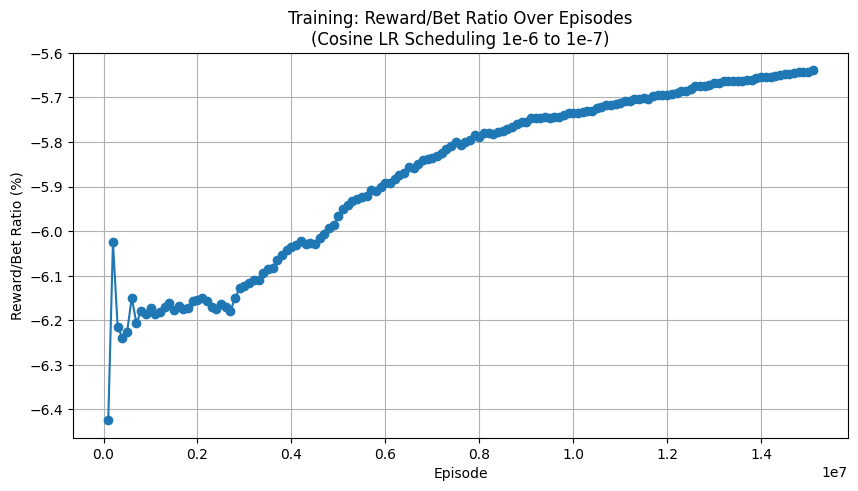

/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unl

Starting evaluation...
Episode 1000: Reward/Bet Ratio = -0.59%
Episode 2000: Reward/Bet Ratio = -3.51%
Episode 3000: Reward/Bet Ratio = -4.31%
Episode 4000: Reward/Bet Ratio = -4.37%
Episode 5000: Reward/Bet Ratio = -4.38%
Episode 6000: Reward/Bet Ratio = -3.77%
Episode 7000: Reward/Bet Ratio = -3.06%
Episode 8000: Reward/Bet Ratio = -3.40%
Episode 9000: Reward/Bet Ratio = -3.86%
Episode 10000: Reward/Bet Ratio = -4.01%
Episode 11000: Reward/Bet Ratio = -4.15%
Episode 12000: Reward/Bet Ratio = -4.74%
Episode 13000: Reward/Bet Ratio = -4.85%
Episode 14000: Reward/Bet Ratio = -4.76%
Episode 15000: Reward/Bet Ratio = -4.86%
Episode 16000: Reward/Bet Ratio = -4.93%
Episode 17000: Reward/Bet Ratio = -5.14%
Episode 18000: Reward/Bet Ratio = -5.08%
Episode 19000: Reward/Bet Ratio = -4.84%
Episode 20000: Reward/Bet Ratio = -5.09%
Episode 21000: Reward/Bet Ratio = -5.29%
Episode 22000: Reward/Bet Ratio = -5.33%
Episode 23000: Reward/Bet Ratio = -5.37%
Episode 24000: Reward/Bet Ratio = -5.24%
Ep

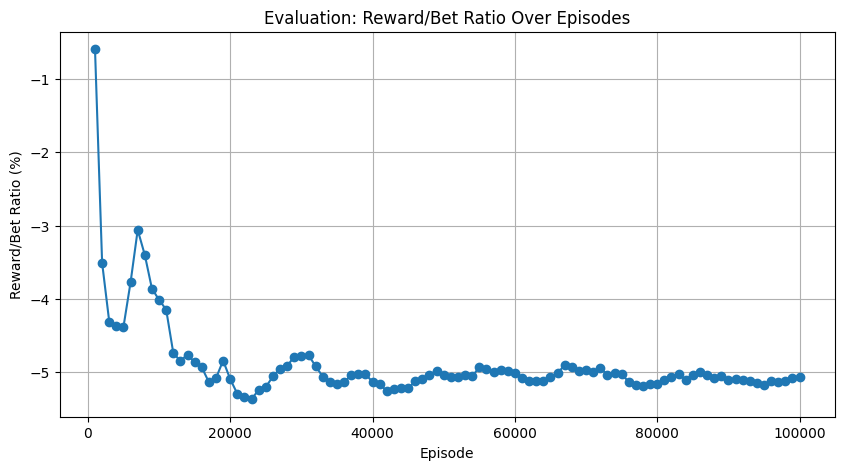

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
from gymnasium.wrappers import RecordEpisodeStatistics
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import math

# ----------------------------
# Environment: Blackjack with Card Counting
# ----------------------------
class BlackjackEnvWithCounting(gym.Env):
    """
    Custom Blackjack environment with card counting.

    State:
      [player_sum, usable_ace, dealer_card, cnt_A, cnt_2, ..., cnt_9, cnt_10group]
    Actions (Discrete(4)):
      0: HIT, 1: STK, 2: DBL, 3: SUR
    """
    def __init__(self, payout_blackjack=1.5, deck_threshold=15):
        super(BlackjackEnvWithCounting, self).__init__()
        self.action_space = spaces.Discrete(4)
        # [player_sum (0-31), usable_ace (2), dealer_card (0-10), counts: 9 values (each 0-4), cnt_10group (0-16)]
        self.observation_space = spaces.MultiDiscrete([32, 2, 11] + [5]*9 + [17])
        self.payout_blackjack = payout_blackjack  
        self.base_bet = 1.0
        self.deck_threshold = deck_threshold  
        self._init_deck()
        self.reset()
        
    def _init_deck(self):
        self.deck = []
        self.deck += ['A'] * 4
        for card in range(2, 10):
            self.deck += [str(card)] * 4
        self.deck += ['10'] * 16  
        random.shuffle(self.deck)
        self.card_counts = {'A': 0}
        for card in range(2, 10):
            self.card_counts[str(card)] = 0
        self.card_counts['10'] = 0
        
    def _draw_card(self):
        if len(self.deck) == 0:
            self._init_deck()
        card = self.deck.pop()
        if card == 'A':
            self.card_counts['A'] = min(self.card_counts['A'] + 1, 4)
        elif card == '10':
            self.card_counts['10'] = min(self.card_counts['10'] + 1, 16)
        else:
            self.card_counts[card] = min(self.card_counts[card] + 1, 4)
        return card
    
    def _hand_value(self, hand):
        total = 0
        ace_count = 0
        for card in hand:
            if card == 'A':
                total += 1
                ace_count += 1
            else:
                total += int(card)
        usable_ace = 0
        if ace_count > 0 and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _card_value(self, card):
        if card == 'A':
            return 1  
        else:
            return int(card)
    
    def _get_observation(self):
        player_sum, usable_ace = self._hand_value(self.player_hand)
        dealer_face_up = self.dealer_hand[0]
        dealer_card_val = self._card_value(dealer_face_up)
        counts = [self.card_counts['A']]
        for card in range(2, 10):
            counts.append(self.card_counts[str(card)])
        counts.append(self.card_counts['10'])
        obs = np.array([player_sum, usable_ace, dealer_card_val] + counts, dtype=np.int32)
        return obs
    
    def reset(self, seed=None, options=None):
        self.first_move = True  
        self.done = False
        if len(self.deck) < self.deck_threshold:
            self._init_deck()
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        if player_total == 21:
            if dealer_total == 21:
                self.done = True
                self.reward = 0.0
            else:
                self.done = True
                self.reward = self.payout_blackjack * self.base_bet
        else:
            self.reward = 0.0
        return self._get_observation(), {}
    
    def step(self, action):
        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                self.done = True
                reward = -self.base_bet
            else:
                reward = 0.0
            self.first_move = False
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 1:  # STK
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 2:  # DBL
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, self.done, False, {}
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 3:  # SUR
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, self.done, False, {}
        
        else:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        while dealer_total < 17:
            card = self._draw_card()
            self.dealer_hand.append(card)
            dealer_total, _ = self._hand_value(self.dealer_hand)
        bet = self.base_bet * (2 if double_down else 1)
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0
    
    def render(self, mode='human'):
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")
        print("Card counts:", self.card_counts)

# ----------------------------
# Custom Wrapper to Attach Bet Information
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action  
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 2.0 if self.last_action == 2 else 1.0
        return obs, reward, terminated, truncated, info

# ----------------------------
# Custom Callback for Training Metrics
# ----------------------------
class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None:
            if isinstance(infos, list):
                for info in infos:
                    if "episode" in info:
                        self.episode_count += 1
                        self.total_reward += info["episode"]["r"]
                        self.total_bet += info.get("bet", 1.0)
                        if self.episode_count % self.print_freq == 0:
                            ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                            print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                                  f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                            self.episode_history.append(self.episode_count)
                            self.ratio_history.append(ratio)
            else:
                if "episode" in infos:
                    self.episode_count += 1
                    self.total_reward += infos["episode"]["r"]
                    self.total_bet += infos.get("bet", 1.0)
                    if self.episode_count % self.print_freq == 0:
                        ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                        print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                              f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                        self.episode_history.append(self.episode_count)
                        self.ratio_history.append(ratio)
        return True

# ----------------------------
# Updated Cosine Learning Rate Schedule (1e-6 to 1e-7)
# ----------------------------
def cosine_lr_schedule(progress_remaining):
    """
    Cosine learning rate schedule.
    Decays the learning rate from 1e-6 to 1e-7 following a cosine schedule.
    progress_remaining: float in [0,1], where 1.0 is the start and 0.0 is the end.
    """
    lr_initial = 1e-6
    lr_min = 1e-7
    cosine_decay = 0.5 * (1 + math.cos(math.pi * (1 - progress_remaining)))
    return lr_min + (lr_initial - lr_min) * cosine_decay

# ----------------------------
# Create the Environment and Wrap It
# ----------------------------
env = BlackjackEnvWithCounting()
env = BetInfoWrapper(env)
env = RecordEpisodeStatistics(env)
check_env(env, warn=True)

# ----------------------------
# Load the Trained Model and Update LR Schedule
# ----------------------------
# Load the saved model from the "kaggle/working" folder
model = PPO.load("model", env=env)
# Update the model's learning rate schedule to the new cosine_lr_schedule
model.lr_schedule = cosine_lr_schedule

# Create the training metrics callback (prints every 100,000 episodes)
metrics_callback = TrainingMetricsCallback(print_freq=100_000, verbose=0)

# ----------------------------
# Further Train the Model for 20,000,000 timesteps with the updated LR schedule
# ----------------------------
model.learn(total_timesteps=20_000_000, callback=metrics_callback)

# Save the further trained model (optional)
model.save("model_further_trained")
print("Further training complete and saved as 'kaggle/working/model_further_trained'.")

# ----------------------------
# Plot the Reward/Bet Ratio Over Episodes (Training)
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(metrics_callback.episode_history, metrics_callback.ratio_history, marker='o', linestyle='-')
plt.title("Training: Reward/Bet Ratio Over Episodes\n(Cosine LR Scheduling 1e-6 to 1e-7)")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

# ----------------------------
# Evaluation
# ----------------------------
eval_env = BlackjackEnvWithCounting()
eval_env = BetInfoWrapper(eval_env)
eval_env = RecordEpisodeStatistics(eval_env)

# Load the further trained model for evaluation
model = PPO.load("model_further_trained", env=eval_env)

num_episodes = 100_000
reward_history = []  
bet_history = []     
ratio_history_eval = []  
episode_x = []           

wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
for episode in range(1, num_episodes + 1):
    obs, _ = eval_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
    episode_reward = reward
    episode_bet = info.get("bet", 1.0)
    
    reward_history.append(episode_reward)
    bet_history.append(episode_bet)
    
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_episodes * 100
draw_percent = draws / num_episodes * 100
loss_percent = losses / num_episodes * 100

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(episode_x, ratio_history_eval, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()